### 1. Imports & Setup

Import the libraries used throughout the notebook and load the raw dataset.
We also create a working copy of the DataFrame so the original data stays unchanged.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

# Configure visualization style
sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported successfully.")

# Load the dataset
df = pd.read_csv('data/customer_info.csv')

# Create a working copy to preserve original data
data = df.copy()

Libraries imported successfully.


### 2. Data Preparation

Prepare the dataset for consistent processing.
This includes setting a reliable index (customer ID when available), removing duplicates, and quickly validating the result.

In [50]:
# Set customer_id as the index
if 'customer_id' in data.columns:
    data.set_index('customer_id', inplace=True)

# Check and remove duplicate rows
initial_count = len(data)
data.drop_duplicates(inplace=True)
dropped_count = initial_count - len(data)

print(f"Original rows: {initial_count}")
print(f"Duplicates dropped: {dropped_count}")
print(f"Current rows: {len(data)}")

# Display the first few rows to verify
display(data.head())

Original rows: 16978
Duplicates dropped: 0
Current rows: 16978


,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
11259,Louis Huffman,male,08/22/1948 05:06 AM,0.0,2.0,2.0,3.0,6238.0,818.0,18.0,...,1039.0,361.0,457.0,1520.0,210.0,0.623414,2000.0,917650.0,38.683897,-9.172942
6538,Msc. Noel Ward,male,02/12/1967 07:51 PM,2.0,1.0,3.0,3.0,4188.0,1048.0,14.0,...,1913.0,562.0,67.0,957.0,92.0,0.555637,2017.0,906928.0,38.790490,-9.115064
14274,Bsc. Scott Giordano,male,04/10/1986 05:10 PM,0.0,0.0,1.0,1.0,25269.0,4047.0,12.0,...,303.0,724.0,442.0,1213.0,85.0,0.259248,2014.0,958107.0,38.775609,-9.112610
7796,William Lacy,male,01/03/1999 01:47 AM,0.0,1.0,1.0,3.0,8292.0,1524.0,15.0,...,1877.0,560.0,1028.0,1005.0,169.0,0.419730,2024.0,967864.0,38.736641,-9.158548
4521,Bsc. Nathan Minor,male,10/21/1957 07:34 AM,3.0,1.0,2.0,3.0,43692.0,3718.0,10.0,...,3093.0,1635.0,868.0,745.0,345.0,0.428821,2004.0,971603.0,38.726597,-9.109803


### 3. Data Cleaning

Handle missing values so later steps (feature engineering and scaling) can run without errors.
Metric (numeric) features are imputed using KNN; non-metric/categorical features are imputed using the most frequent value (mode).

In [51]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# ---------------------------------------------------------
# SETUP: Feature Classification
# ---------------------------------------------------------
# Identifiers / Descriptors / Categories
non_metric_features = [
    'customer_name',
    'customer_gender',
    'customer_birthdate',
    'loyalty_card_number',
    'latitude',
    'longitude',
    'year_first_transaction',
    'typical_hour', 
]

# 1. Count Metrics (Integers like 0, 1, 2) -> Use MANUAL LIMITS
count_features = [
    'kids_home', 
    'teens_home', 
    'number_complaints', 
    'distinct_stores_visited',
]

# 2. Continuous Metrics (Money, Time) -> Use CUSTOM IQR
spending_features = [
    'lifetime_spend_groceries', 
    'lifetime_spend_electronics', 
    'lifetime_spend_vegetables', 
    'lifetime_spend_nonalcohol_drinks', 
    'lifetime_spend_alcohol_drinks', 
    'lifetime_spend_meat', 
    'lifetime_spend_fish', 
    'lifetime_spend_hygiene', 
    'lifetime_spend_videogames', 
    'lifetime_spend_petfood', 
    'lifetime_total_distinct_products', 
    'percentage_of_products_bought_promotion'
]

# Combined list for Imputation
metric_features = count_features + spending_features

# Keep only columns that actually exist
non_metric_features = [c for c in non_metric_features if c in data.columns]
metric_features = [c for c in metric_features if c in data.columns]

# Warning for unclassified columns
unclassified_cols = [c for c in data.columns if c not in set(metric_features + non_metric_features)]
if unclassified_cols:
    print('Warning: Unclassified columns:', unclassified_cols)

# ---------------------------------------------------------
# STEP 1: Metric Imputation (Common to both approaches)
# ---------------------------------------------------------
data[metric_features] = data[metric_features].apply(pd.to_numeric, errors='coerce')

print("Applying KNN Imputation...")
imputer = KNNImputer(n_neighbors=5)
data[metric_features] = imputer.fit_transform(data[metric_features])

# ---------------------------------------------------------
# STEP 2 & 3: Branching Approaches for Non-Metric Data
# ---------------------------------------------------------

# === Approach A: Fill with Mode ===
data_mode = data.copy()
for col in non_metric_features:
    mode_values = data_mode[col].mode(dropna=True)
    if not mode_values.empty:
        data_mode[col] = data_mode[col].fillna(mode_values.iloc[0])

print(f"Approach A (Mode) Missing Values: {data_mode.isnull().sum().sum()}")

# === Approach B: Fill with 'Unknown' ===
data_unknown = data.copy()
for col in non_metric_features:
    data_unknown[col] = data_unknown[col].fillna("Unknown")

print(f"Approach B (Unknown) Missing Values: {data_unknown.isnull().sum().sum()}")

Missing values per column:
 customer_birthdate                 68
kids_home                          85
teens_home                         68
number_complaints                  51
distinct_stores_visited           170
typical_hour                       68
lifetime_spend_vegetables          85
lifetime_spend_alcohol_drinks     170
lifetime_spend_fish               170
loyalty_card_number              3143
dtype: int64
Applying KNN Imputation...
Approach A (Mode) Missing Values: 0
Approach B (Unknown) Missing Values: 0


### 4. Detect and Remove Outliers

Inspect and mitigate extreme values that could distort scaling and clustering.
We use visual diagnostics (e.g., boxplots) and apply an outlier treatment strategy before proceeding.

#### 4.1 Indetifying skewed features

Without identifying first the skewed features the outliers removal was greater than 26%.

Skewness Scores:
lifetime_spend_videogames                  2.985067
lifetime_spend_electronics                 2.015034
distinct_stores_visited                    1.679959
kids_home                                  1.059717
number_complaints                          0.949913
lifetime_spend_groceries                   0.940907
lifetime_spend_hygiene                     0.918478
lifetime_spend_meat                        0.826716
teens_home                                 0.727090
lifetime_total_distinct_products           0.724273
lifetime_spend_alcohol_drinks              0.699657
lifetime_spend_fish                        0.671377
lifetime_spend_vegetables                  0.649625
lifetime_spend_nonalcohol_drinks           0.585014
percentage_of_products_bought_promotion    0.423490
lifetime_spend_petfood                     0.057373
dtype: float64


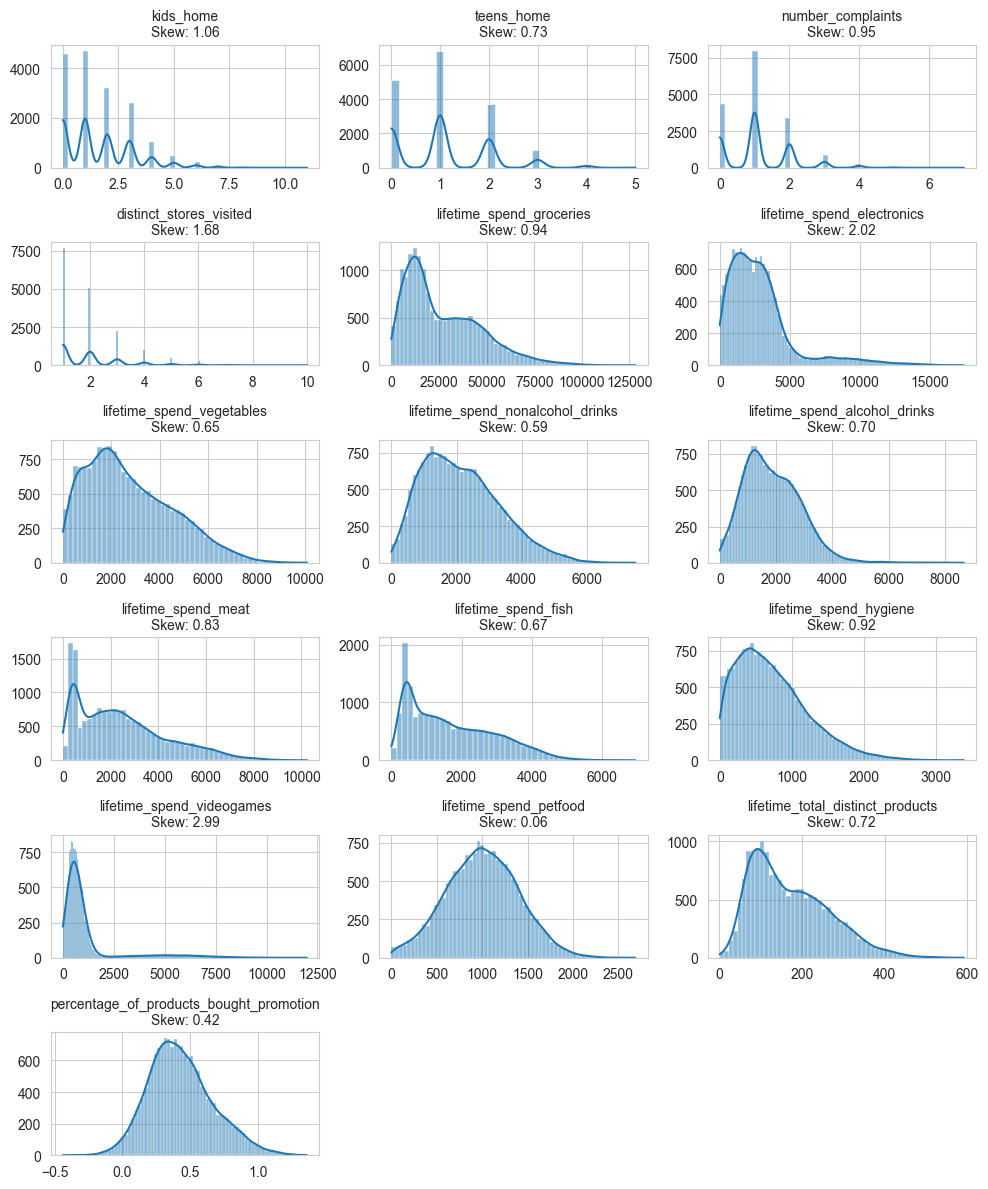

In [52]:
# Ensure numeric types
data[metric_features] = data[metric_features].apply(pd.to_numeric, errors='coerce')

# Calculate Skewness
skewness = data[metric_features].skew().sort_values(ascending=False)
print("Skewness Scores:")
print(skewness)

# Plot Distributions
n_cols = 3
n_rows = (len(metric_features) + n_cols - 1) // n_cols

plt.figure(figsize=(10, 2 * n_rows))

for i, col in enumerate(metric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f"{col}\nSkew: {skewness[col]:.2f}", fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

#### 4.2. Outliers removal

For highly skewed spending variables, we chose Winsorization (Capping) over removal to preserve high-value customer segments, which are critical for business analysis.

Capping creates a "Ceiling." Everyone above the ceiling is treated as "Maximum Value."
Does it move them? Yes, it pulls them closer to the center.
Do they belong in a different cluster? Usually no. They belong in the "Highest Value Cluster," and capping ensures they stay there without breaking the math for everyone else.

In [53]:
# ---------------------------------------------------------
# REPLACEMENT: Capping Outliers (Winsorization)
# ---------------------------------------------------------
def cap_outliers(df, threshold_dict):
    """
    Instead of removing rows, we cap values at the upper limit.
    This preserves data (0% loss) while fixing outliers.
    """
    df_clean = df.copy()
    
    # Apply capping logic
    for col, thresh in threshold_dict.items():
        # Calculate the Upper Limit only
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        upper_limit = Q3 + thresh * IQR
        
        # Check how many would be capped (just for info)
        outliers = df_clean[col] > upper_limit
        if outliers.sum() > 0:
            print(f"Capping {outliers.sum()} values in {col} at {upper_limit:.2f}")
            
            # The Magic Line: Cap values > limit to the limit
            df_clean.loc[df_clean[col] > upper_limit, col] = upper_limit
            
    return df_clean

# ---------------------------------------------------------
# DEFINE LIMITS (Only for skewed spending columns)
# ---------------------------------------------------------
capping_rules = {
    # High Skew -> Cap at 3.0 or 4.5 IQR (Keep the "Whale" status but remove extreme excess)
    'lifetime_spend_videogames': 3.0,   
    'lifetime_spend_electronics': 3.0,  
    'distinct_stores_visited': 3.0, 
    
    # Moderate Skew -> Cap at 1.5 IQR
    'lifetime_spend_groceries': 1.5,
    'lifetime_spend_meat': 1.5,
    # Add others if you want to cap them too
}

# ---------------------------------------------------------
# EXECUTE
# ---------------------------------------------------------
print("--- Approach A (Capping) ---")
# First, apply the Business Logic (Kids/Complaints) using Filter
# (We still drop these because >5 kids is likely an error, not a 'cap')
data_mode_clean = data_mode[
    (data_mode['kids_home'] <= 5) & 
    (data_mode['number_complaints'] <= 20)
].copy()

# Now apply Capping to spending
data_mode_clean = cap_outliers(data_mode_clean, capping_rules)
print(f"Final shape: {data_mode_clean.shape}")
print(f"Data Loss: {100 - (len(data_mode_clean)/len(data_mode)*100):.2f}% (Should be minimal)")

print("\n--- Approach B (Capping) ---")
# Apply Business Logic first
data_unknown_clean = data_unknown[
    (data_unknown['kids_home'] <= 5) & 
    (data_unknown['number_complaints'] <= 20)
].copy()

# Apply Capping
data_unknown_clean = cap_outliers(data_unknown_clean, capping_rules)

--- Approach A (Capping) ---
Capping 1646 values in lifetime_spend_videogames at 2727.00
Capping 374 values in lifetime_spend_electronics at 10521.00
Capping 386 values in distinct_stores_visited at 5.00
Capping 195 values in lifetime_spend_groceries at 82518.00
Capping 185 values in lifetime_spend_meat at 7372.00
Final shape: (16605, 24)
Data Loss: 2.20% (Should be minimal)

--- Approach B (Capping) ---
Capping 1646 values in lifetime_spend_videogames at 2727.00
Capping 374 values in lifetime_spend_electronics at 10521.00
Capping 386 values in distinct_stores_visited at 5.00
Capping 195 values in lifetime_spend_groceries at 82518.00
Capping 185 values in lifetime_spend_meat at 7372.00


### 5. Featura Engineering

Create more informative variables from the raw columns to better represent customer behavior.
This can include derived fields (totals, tenure, age-like features) and dropping identifiers or non-modeling fields.

In [54]:
# 1. Age Calculation
# Convert birthdate to datetime and extract year
data['customer_birthdate'] = pd.to_datetime(data['customer_birthdate'])
current_year = 2025  # Assuming the report year is 2025
data['Age'] = current_year - data['customer_birthdate'].dt.year

# 2. Customer Tenure
data['Customer_Tenure'] = current_year - data['year_first_transaction']

# 3. Total Lifetime Spend (Summing all category spends)
spend_columns = [col for col in data.columns if 'lifetime_spend_' in col]
data['Total_Lifetime_Spend'] = data[spend_columns].sum(axis=1)

# 4. Total Minors (Kids + Teens)
data['Total_Minors'] = data['kids_home'] + data['teens_home']

# 5. Binary Encoding for Gender
# Group 13 created 'Is_Female' dummy variable
data['Is_Female'] = data['customer_gender'].apply(lambda x: 1 if str(x).lower().strip() in ['female', 'f'] else 0)

# Drop columns that are no longer needed
cols_to_drop = ['customer_name', 'customer_gender', 'customer_birthdate', 
                'year_first_transaction', 'loyalty_card_number', 'latitude', 'longitude']
data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

display(data[['Age', 'Customer_Tenure', 'Total_Lifetime_Spend', 'Is_Female']].head())

,Age,Customer_Tenure,Total_Lifetime_Spend,Is_Female
customer_id,,,,
11259,77.0,25.0,17056.0,0
6538,58.0,8.0,18675.0,0
14274,39.0,11.0,40362.0,0
7796,26.0,1.0,21337.0,0
4521,68.0,21.0,71789.0,0


### 6. Correlations

Analyze relationships between numerical variables.
A correlation heatmap helps identify redundant features and understand which variables move together.

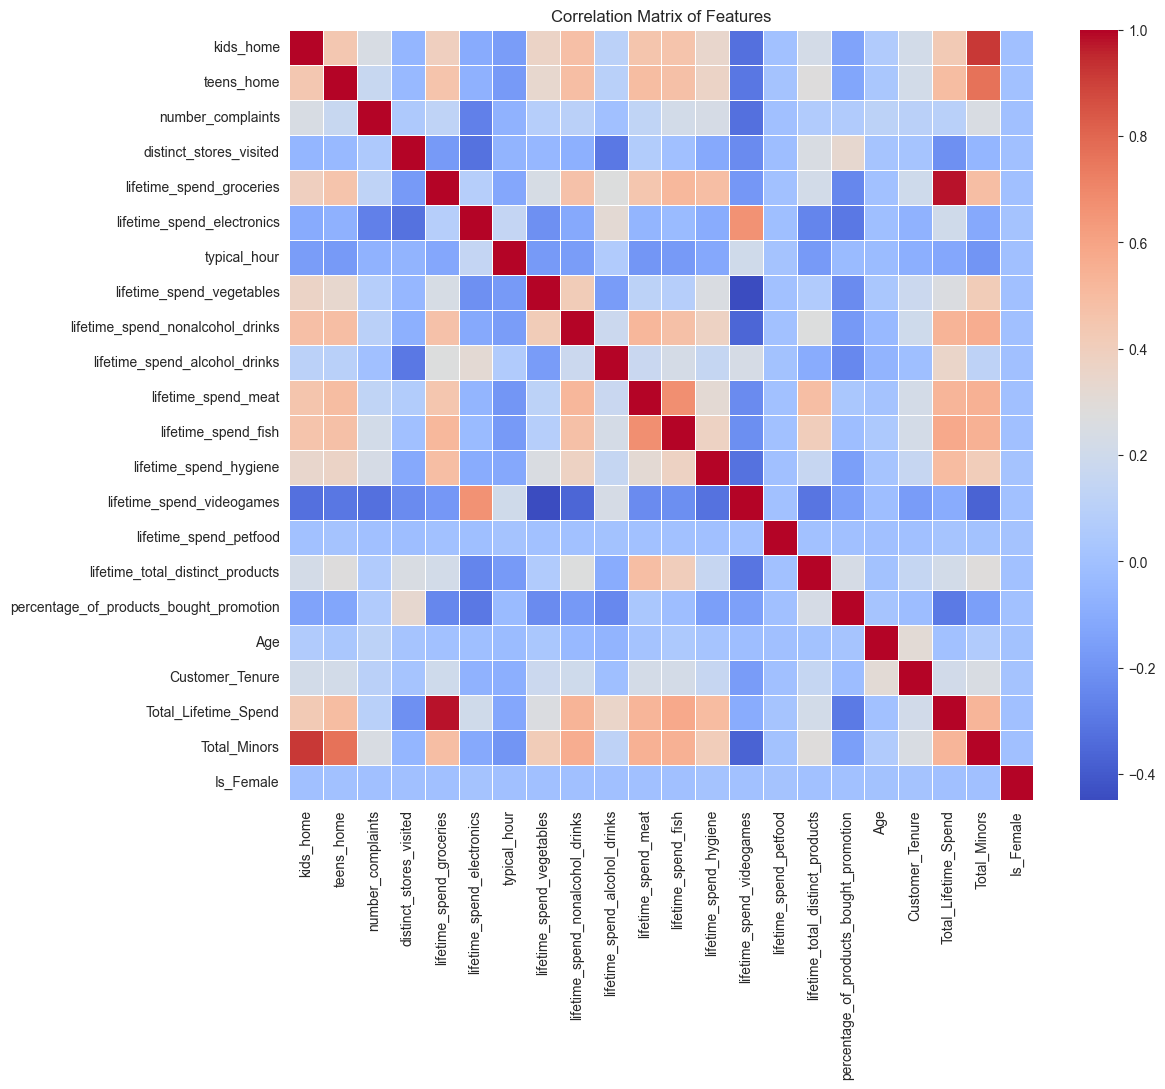

Correlation with Total Spend:

Total_Lifetime_Spend                1.000000
lifetime_spend_groceries            0.980348
lifetime_spend_fish                 0.577446
lifetime_spend_nonalcohol_drinks    0.534097
lifetime_spend_meat                 0.527656
Name: Total_Lifetime_Spend, dtype: float64


In [55]:
plt.figure(figsize=(12, 10))
correlation_matrix = data.corr()

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# Optional: Check correlation with Total Spend to see drivers
print("Correlation with Total Spend:\n")
print(correlation_matrix['Total_Lifetime_Spend'].sort_values(ascending=False).head(5))

### 7. Scaling

Scale features so variables with large numeric ranges don’t dominate distance-based clustering.
Robust scaling is used to reduce sensitivity to remaining outliers.

In [56]:
# Initialize RobustScaler
scaler = RobustScaler()

# Fit and transform the data
data_scaled_array = scaler.fit_transform(data)

# Convert back to DataFrame for readability and further analysis
data_scaled = pd.DataFrame(data_scaled_array, columns=data.columns, index=data.index)

print("Scaling complete. Data is ready for clustering (Group 5).")
display(data_scaled.head())

Scaling complete. Data is ready for clustering (Group 5).


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,Age,Customer_Tenure,Total_Lifetime_Spend,Total_Minors,Is_Female
customer_id,,,,,,,,,,,,,,,,,,,,,
11259,-0.333333,0.5,0.5,1.0,-0.503204,-0.673392,0.375,-0.334871,-0.307011,-0.114894,...,-0.414562,-0.323171,0.943431,0.410072,0.695476,0.741935,1.875,-0.550103,0.000000,-1.0
6538,0.333333,0.0,1.0,1.0,-0.574125,-0.573598,-0.125,-0.139946,-0.265683,0.719149,...,-0.115899,-1.002613,-0.083942,-0.438849,0.477321,0.129032,-0.250,-0.507421,0.333333,-1.0
14274,-0.333333,-0.5,0.0,-1.0,0.155177,0.727628,-0.375,0.953864,0.211365,-0.804965,...,0.124814,-0.349303,0.383212,-0.489209,-0.476672,-0.483871,0.125,0.064312,-0.666667,-1.0
7796,-0.333333,0.0,0.0,1.0,-0.432146,-0.367068,0.000,-0.054979,-0.796458,-0.453901,...,-0.118871,0.671603,0.003650,0.115108,0.039874,-0.903226,-1.125,-0.437243,-0.333333,-1.0
4521,0.666667,0.0,0.5,1.0,0.792524,0.584879,-0.625,1.401000,0.599262,0.164539,...,1.478455,0.392857,-0.470803,1.381295,0.069137,0.451613,1.375,0.892821,0.666667,-1.0


### 8. Save Output

Export the final processed dataset.
This file is used as input for the clustering step in the next notebook.

In [57]:
data_scaled.to_csv('data/processed_customer_data.csv')